Engine Specifications:
Bore: 93 mm
Stroke: 92 mm
Conrod length: 156 mm
Clearance volume: 36.8 cm³
Displacement volume: 624.9 cm³
Compression ratio: 18.0:1


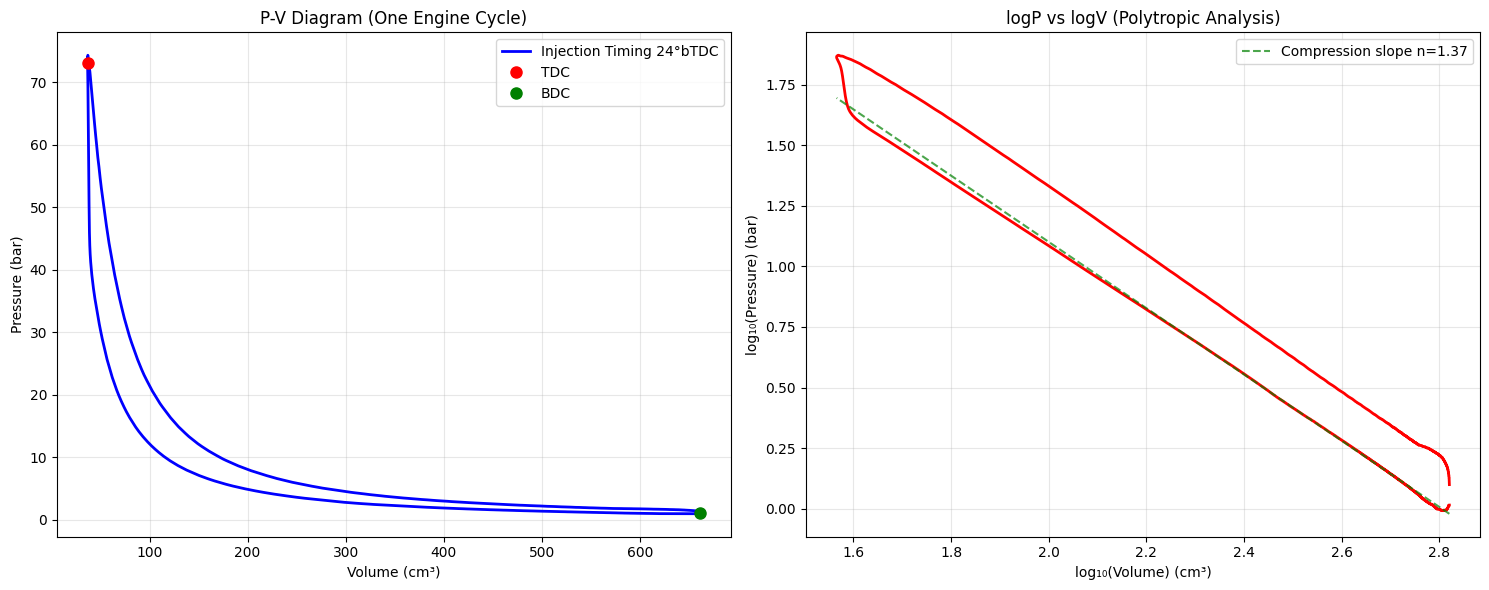


=== ENGINE CYCLE ANALYSIS ===
Cycle range: -180.0° to 180.0°
Volume range: 36.76 - 661.71 cm³
Peak pressure: 74.29 bar @ +2.2°
TDC pressure: 73.10 bar
BDC pressure: 1.04 bar
Approximate net work: 221.08 J/cycle
Polytropic constant (compression): 1.37


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# ===============================================
# ENGINE GEOMETRY PARAMETERS (TYPICAL VALUES)
# ===============================================
bore = 0.093          # Bore diameter: 93 mm (typical single-cylinder diesel)
stroke = 0.092        # Stroke length: 92 mm
crank_radius = stroke / 2  # = 0.043 m (r)
conrod_length = 0.156     # Connecting rod length: 156 mm
v_swept = np.pi*(bore/2)**2*stroke;
rc = 18; # comp ratio is 18
## Vs+Vc/vc =18 -> Vs/vc = 17;
clearance_volume = v_swept/(rc-1); # Clearance volume: 12 cm³ (CR ≈ 16:1 typical diesel)

# Derived parameters
piston_area = np.pi * (bore/2)**2  # m²
disp_volume = piston_area * stroke # m³ (displacement volume)

print("Engine Specifications:")
print(f"Bore: {bore*1000:.0f} mm")
print(f"Stroke: {stroke*1000:.0f} mm")
print(f"Conrod length: {conrod_length*1000:.0f} mm")
print(f"Clearance volume: {clearance_volume*1e6:.1f} cm³")
print(f"Displacement volume: {disp_volume*1e6:.1f} cm³")
print(f"Compression ratio: {rc:.1f}:1")

# ===============================================
# READ AND PROCESS DATA
# ===============================================
data = pd.read_csv('Injection_Timing_24bTDC.txt', sep='\t|\r', engine='python',
                   names=['crank_angle', 'pressure_bar'], skiprows=2)

# Convert columns to numeric, coercing errors
data['crank_angle'] = pd.to_numeric(data['crank_angle'], errors='coerce')
data['pressure_bar'] = pd.to_numeric(data['pressure_bar'], errors='coerce')

data = data.dropna().reset_index(drop=True)

# Focus on one complete cycle (-180° to 180° around TDC)
mask = (data['crank_angle'] >= -180) & (data['crank_angle'] <= 180)
cycle_data = data.loc[mask].reset_index(drop=True)

theta_deg = cycle_data['crank_angle'].values
theta_rad = np.radians(theta_deg)
P_bar = cycle_data['pressure_bar'].values

# ===============================================
# CYLINDER VOLUME CALCULATION
# ===============================================
def cylinder_volume(theta_rad, r=crank_radius, l=conrod_length,
                   Vc=clearance_volume, A=piston_area):
    """
    Calculate instantaneous cylinder volume from crank angle
    V(θ) = Vc + A * [r(1-cosθ) + l - sqrt(l² - (r*sinθ)²)]
    """
    s = r * (1 - np.cos(theta_rad)) + l - np.sqrt(l**2 - (r * np.sin(theta_rad))**2)
    V = Vc + A * s  # in m³
    return V * 1e6  # Convert to cm³ for plotting

# Calculate volumes
V_cm3 = cylinder_volume(theta_rad)

# ===============================================
# CREATE P-V AND logP-logV PLOTS
# ===============================================
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# P-V Diagram
ax1.plot(V_cm3, P_bar, 'b-', linewidth=2, label='Injection Timing 24°bTDC')
ax1.set_xlabel('Volume (cm³)')
ax1.set_ylabel('Pressure (bar)')
ax1.set_title('P-V Diagram (One Engine Cycle)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Mark key points
tdc_idx = np.argmin(V_cm3)
bdc_idx = np.argmax(V_cm3)
ax1.plot(V_cm3[tdc_idx], P_bar[tdc_idx], 'ro', markersize=8, label='TDC')
ax1.plot(V_cm3[bdc_idx], P_bar[bdc_idx], 'go', markersize=8, label='BDC')
ax1.legend()

# logP vs logV (for polytropic analysis)
mask_log = (P_bar > 0.1) & (V_cm3 > 0)  # Avoid log(0)
logV = np.log10(V_cm3[mask_log])
logP = np.log10(P_bar[mask_log])

ax2.plot(logV, logP, 'r-', linewidth=2)
ax2.set_xlabel('log₁₀(Volume) (cm³)')
ax2.set_ylabel('log₁₀(Pressure) (bar)')
ax2.set_title('logP vs logV (Polytropic Analysis)')
ax2.grid(True, alpha=0.3)

# Add polytropic slope reference lines
# Define compression range using the indices from BDC to TDC
# bdc_idx is 0 (for -180 degrees)
# tdc_idx is ~1800 (for 0 degrees)
compression_indices_for_fit = np.arange(bdc_idx, tdc_idx + 1) # +1 to include tdc_idx

polytropic_constant = None
if len(compression_indices_for_fit) > 10:
    # Filter logV and logP using the selected indices for compression
    logV_compression_fit = logV[compression_indices_for_fit]
    logP_compression_fit = logP[compression_indices_for_fit]

    p = np.polyfit(logV_compression_fit, logP_compression_fit, 1)
    polytropic_constant = -p[0] # Take the negative of the slope to get n
    ax2.plot(logV_compression_fit, p[0]*logV_compression_fit + p[1], 'g--', alpha=0.7,
             label=f'Compression slope n={polytropic_constant:.2f}')
    ax2.legend()

plt.tight_layout()
plt.savefig('PV_logP_logV_24bTDC.png', dpi=300, bbox_inches='tight')
plt.show()

# ===============================================
# ANALYSIS RESULTS
# ===============================================
print("\n=== ENGINE CYCLE ANALYSIS ===")
print(f"Cycle range: {theta_deg[0]:.1f}° to {theta_deg[-1]:.1f}°")
print(f"Volume range: {V_cm3.min():.2f} - {V_cm3.max():.2f} cm³")
print(f"Peak pressure: {P_bar.max():.2f} bar @ {theta_deg[np.argmax(P_bar)]:+.1f}°")
print(f"TDC pressure: {P_bar[tdc_idx]:.2f} bar")
print(f"BDC pressure: {P_bar[bdc_idx]:.2f} bar")

# Calculate indicated work (approximate) - Corrected calculation for area enclosed by P-V diagram
# The integral of P dV is sum(P * dV)
# We convert P from bar to Pa (1 bar = 1e5 Pa) and V from cm³ to m³ (1 cm³ = 1e-6 m³)
net_work = np.sum(P_bar[:-1] * np.diff(V_cm3)) * 1e5 * 1e-6  # J
print(f"Approximate net work: {net_work:.2f} J/cycle")
if polytropic_constant is not None:
    print(f"Polytropic constant (compression): {polytropic_constant:.2f}")

### Heat Release Rate Calculation

The heat release rate ($
rac{dQ}{d\theta}$) is calculated using the first law of thermodynamics for a closed system, often expressed as:

$\frac{dQ}{d\theta} = \frac{\gamma}{\gamma - 1} P \frac{dV}{d\theta} + \frac{1}{\gamma - 1} V \frac{dP}{d\theta}$

Where:
*   $P$ is the cylinder pressure.
*   $V$ is the cylinder volume.
*   $\theta$ is the crank angle.
*   $\gamma$ is the ratio of specific heats (adiabatic index).

For this calculation, we will assume a typical value for $\gamma$ of 1.35. This value can vary depending on the temperature and composition of the cylinder gases.

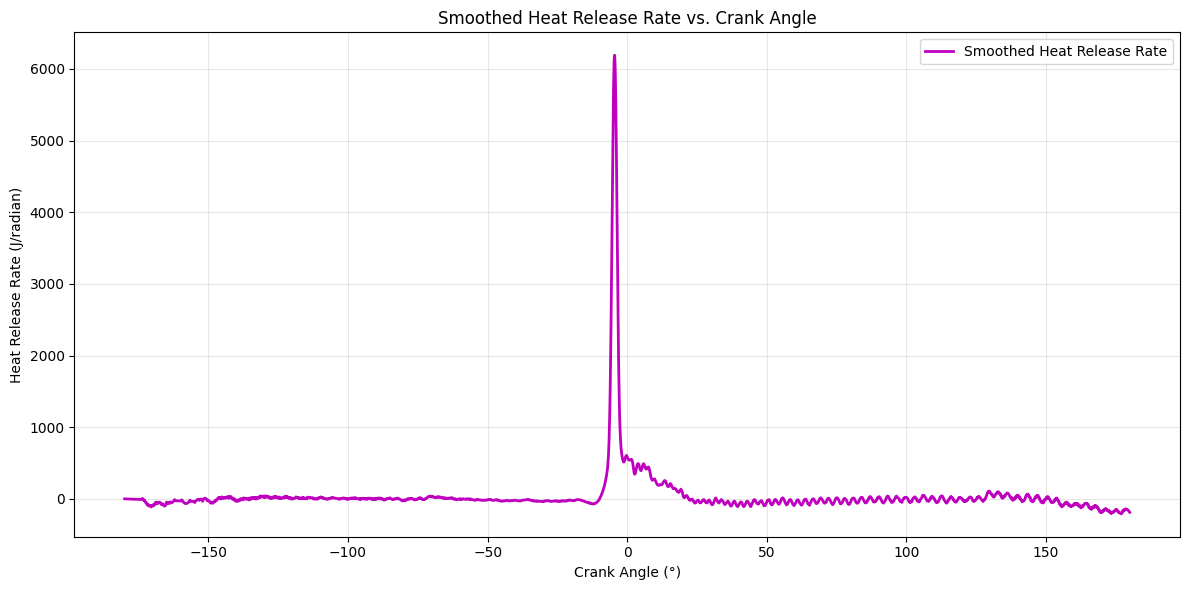

Assumed gamma (ratio of specific heats): 1.35
Savitzky-Golay filter applied with window_length=31 and poly_order=3


In [ ]:
# ===============================================
# HEAT RELEASE RATE CALCULATION
# ===============================================

from scipy.signal import savgol_filter

# Define the ratio of specific heats (gamma)
gamma = 1.35 # Typical value for combustion products in diesel engines

# Convert pressure from bar to Pascals (1 bar = 1e5 Pa)
P_Pa = P_bar * 1e5

# Convert volume from cm³ to m³ (1 cm³ = 1e-6 m³)
V_m3 = V_cm3 * 1e-6

# --- Apply Savitzky-Golay filter to smooth P and V data ---
# Window length should be odd and smaller than the total number of data points
# polyorder is the order of the polynomial used to fit the samples
window_length = 31 # This value can be adjusted for desired smoothing
poly_order = 3     # This value can be adjusted

# Ensure window_length is less than the data length
if window_length >= len(P_Pa):
    window_length = len(P_Pa) - 1 if len(P_Pa) % 2 == 0 else len(P_Pa)
    if window_length < 3: # Ensure minimum window length for Savitzky-Golay
        window_length = 3

P_Pa_smoothed = savgol_filter(P_Pa, window_length, poly_order)
V_m3_smoothed = savgol_filter(V_m3, window_length, poly_order)

# Calculate derivatives dV/dtheta and dP/dtheta with respect to crank angle in radians
# np.gradient calculates the derivative using central differences
dV_dtheta_smoothed = np.gradient(V_m3_smoothed, theta_rad)
dP_dtheta_smoothed = np.gradient(P_Pa_smoothed, theta_rad)

# Calculate Heat Release Rate (dQ/dtheta)
# dQ/dtheta = [gamma/(gamma-1)] * P * (dV/dtheta) + [1/(gamma-1)] * V * (dP/dtheta)
dQ_dtheta_smoothed = (gamma / (gamma - 1)) * P_Pa_smoothed * dV_dtheta_smoothed + \
                     (1 / (gamma - 1)) * V_m3_smoothed * dP_dtheta_smoothed

# ===============================================
# CREATE SMOOTHED HEAT RELEASE RATE PLOT
# ===============================================
plt.figure(figsize=(12, 6))
plt.plot(theta_deg, dQ_dtheta_smoothed, 'm-', linewidth=2, label='Smoothed Heat Release Rate')
plt.xlabel('Crank Angle (°)')
plt.ylabel('Heat Release Rate (J/radian)')
plt.title('Smoothed Heat Release Rate vs. Crank Angle')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('Smoothed_HeatReleaseRate_CrankAngle_24bTDC.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Assumed gamma (ratio of specific heats): {gamma}")
print(f"Savitzky-Golay filter applied with window_length={window_length} and poly_order={poly_order}")

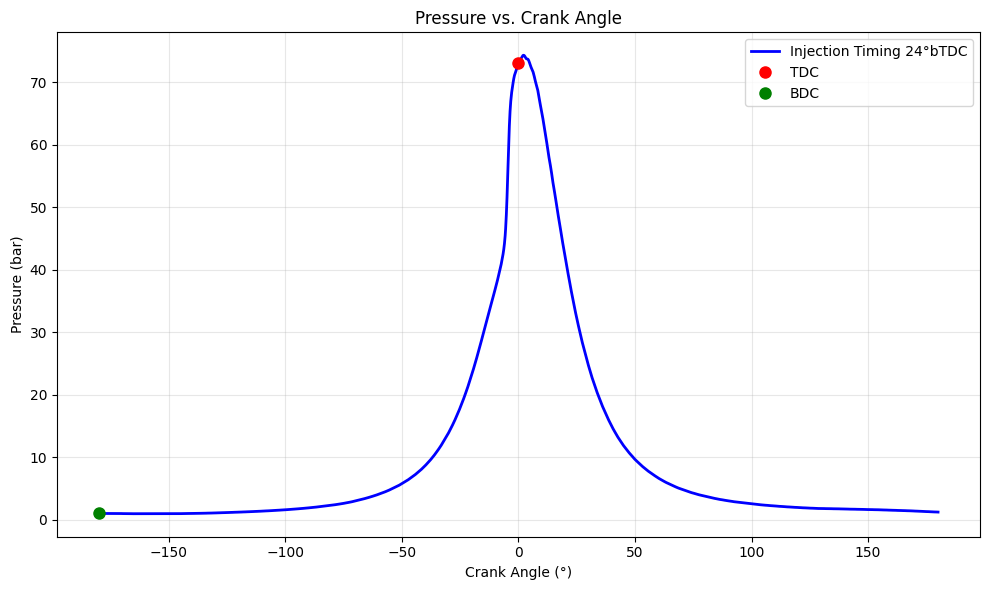

In [ ]:
import matplotlib.pyplot as plt

# Create Pressure vs. Crank Angle plot
plt.figure(figsize=(10, 6))
plt.plot(theta_deg, P_bar, 'b-', linewidth=2, label='Injection Timing 24°bTDC')
plt.xlabel('Crank Angle (°)')
plt.ylabel('Pressure (bar)')
plt.title('Pressure vs. Crank Angle')
plt.grid(True, alpha=0.3)
plt.legend()

# Mark key points
tdc_idx = np.argmin(V_cm3)
bdc_idx = np.argmax(V_cm3)
plt.plot(theta_deg[tdc_idx], P_bar[tdc_idx], 'ro', markersize=8, label='TDC')
plt.plot(theta_deg[bdc_idx], P_bar[bdc_idx], 'go', markersize=8, label='BDC')
plt.legend()
plt.tight_layout()
plt.savefig('Pressure_CrankAngle_24bTDC.png', dpi=300, bbox_inches='tight')
plt.show()

You can upload files in Google Colab using one of these methods:

1.  **Using the file browser:**
    *   On the left sidebar, click the folder icon to open the 'Files' tab.
    *   Click the 'Upload to session storage' icon (it looks like a page with an arrow pointing up).
    *   Select the file(s) from your local computer.
    *   *Note: Files uploaded this way will be deleted when the runtime disconnects.*

2.  **Using `files.upload()` in Python:**
    *   Run the following Python code in a cell. A button will appear allowing you to select files from your local system.


In [ ]:
from google.colab import files

uploaded = files.upload()

3.  **Mounting Google Drive:**
    *   You can mount your Google Drive to access files directly from there. This is persistent across sessions.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

300kPa: Peak 57.98 bar at 10.0°
350kPa: Peak 58.88 bar at 9.3°
400kPa: Peak 60.41 bar at 8.4°
450kPa: Peak 61.95 bar at 8.4°
500kPa: Peak 62.28 bar at 7.7°
550kPa: Peak 63.26 bar at 7.8°
600kPa: Peak 63.07 bar at 7.7°
650kPa: Peak 61.58 bar at 7.5°


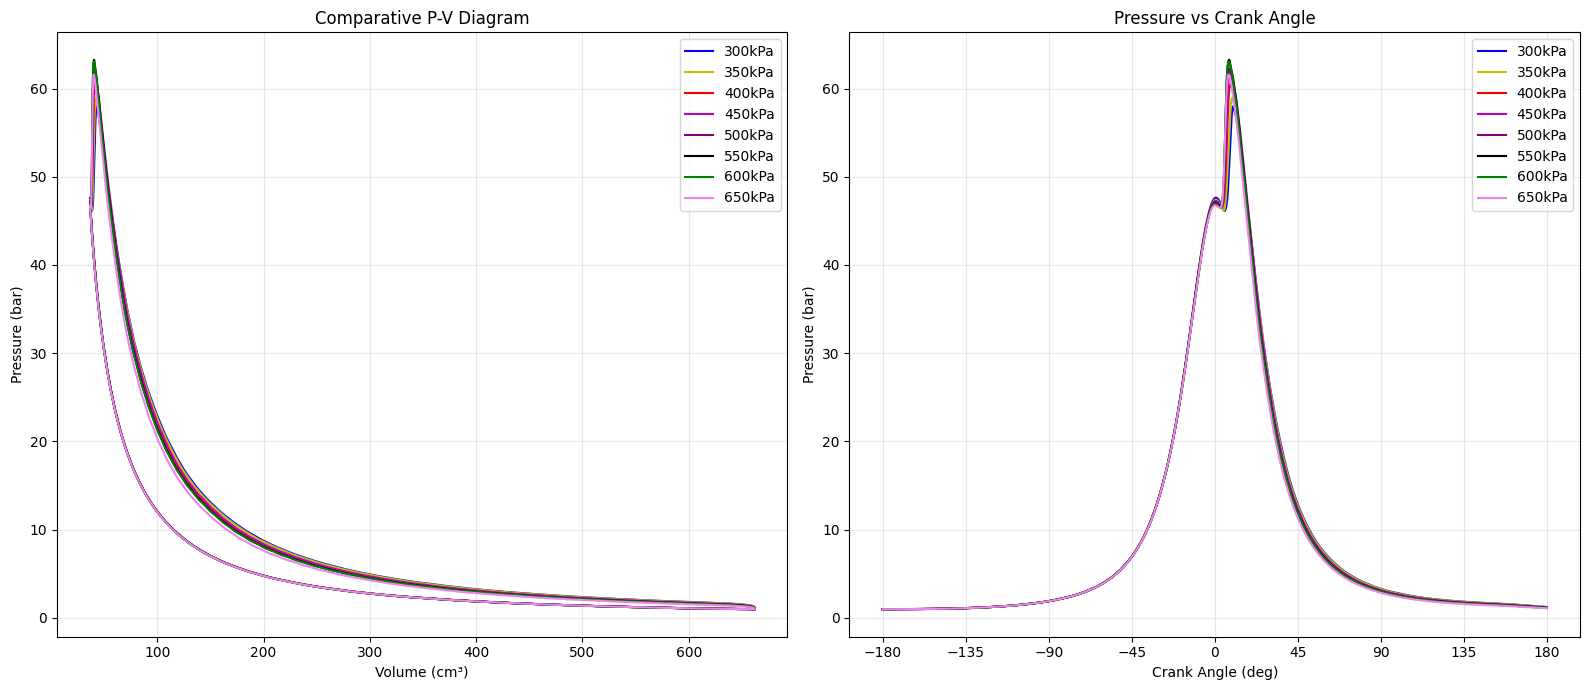

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================================
# ENGINE GEOMETRY PARAMETERS (STAY THE SAME)
# ===============================================
bore, stroke = 0.093, 0.092
crank_radius = stroke / 2
conrod_length = 0.156
rc = 18
v_swept = np.pi * (bore/2)**2 * stroke
clearance_volume = v_swept / (rc - 1)
piston_area = np.pi * (bore/2)**2

def cylinder_volume(theta_deg):
    theta_rad = np.radians(theta_deg)
    s = crank_radius * (1 - np.cos(theta_rad)) + conrod_length - np.sqrt(conrod_length**2 - (crank_radius * np.sin(theta_rad))**2)
    return (clearance_volume + piston_area * s) * 1e6  # cm³

# ===============================================
# CONFIGURATION: LIST YOUR FILES HERE
# ===============================================
# Add all your filenames and their labels to this list
files_to_process = [
    {'file': 'Injection_Pressure_300kPa.txt', 'label': '300kPa', 'color': 'b'},
    {'file': 'Injection_Pressure_350kPa.txt', 'label': '350kPa', 'color': 'y'},
    {'file': 'Injection_Pressure_400kPa.txt', 'label': '400kPa', 'color': 'r'},
    {'file': 'Injection_Pressure_450kPa.txt', 'label': '450kPa', 'color': 'm'},
    {'file': 'Injection_Pressure_500kPa.txt', 'label': '500kPa', 'color': 'purple'},
    {'file': 'Injection_Pressure_550kPa.txt', 'label': '550kPa', 'color': 'k'},
    {'file': 'Injection_Pressure_600kPa.txt', 'label': '600kPa', 'color': 'g'},
    {'file': 'Injection_Pressure_650kPa.txt', 'label': '650kPa', 'color': 'violet'}, # Changed 'v' to 'violet'
]

# Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# ===============================================
# PROCESSING LOOP
# ===============================================
for entry in files_to_process:
    try:
        # Read Data
        df = pd.read_csv(entry['file'], sep='\t|\r', engine='python',
                         names=['crank_angle', 'pressure_bar'], skiprows=2)
        df = df.apply(pd.to_numeric, errors='coerce').dropna().reset_index(drop=True)

        # Filter for one cycle (-180 to 180)
        mask = (df['crank_angle'] >= -180) & (df['crank_angle'] <= 180)
        cycle_data = df.loc[mask]

        theta = cycle_data['crank_angle'].values
        P_bar = cycle_data['pressure_bar'].values
        V_cm3 = cylinder_volume(theta) # Volume is same for all files

        # --- Plot 1: P-V Diagram ---
        ax1.plot(V_cm3, P_bar, label=entry['label'], color=entry['color'], linewidth=1.5)

        # --- Plot 2: P-theta (Crank Angle) Diagram ---
        # This is often more useful for seeing injection timing effects
        ax2.plot(theta, P_bar, label=entry['label'], color=entry['color'], linewidth=1.5)

        # Print Peak Pressure Analysis
        peak_p = P_bar.max()
        peak_angle = theta[np.argmax(P_bar)]
        print(f"{entry['label']}: Peak {peak_p:.2f} bar at {peak_angle:.1f}°")

    except FileNotFoundError:
        print(f"Warning: {entry['file']} not found. Skipping.")

# ===============================================
# FINAL STYLING
# ===============================================
# Style P-V Plot
ax1.set_xlabel('Volume (cm³)')
ax1.set_ylabel('Pressure (bar)')
ax1.set_title('Comparative P-V Diagram')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Style P-theta Plot
ax2.set_xlabel('Crank Angle (deg)')
ax2.set_ylabel('Pressure (bar)')
ax2.set_title('Pressure vs Crank Angle')
ax2.set_xticks(np.arange(-180, 181, 45))
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

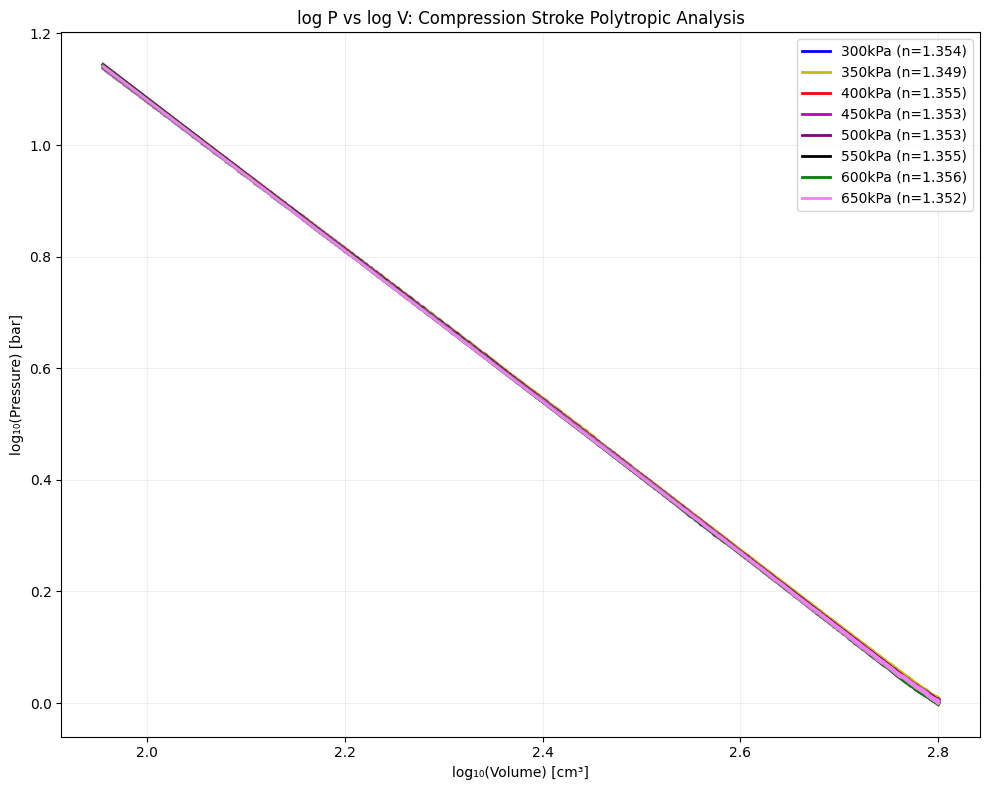


--- Summary of Polytropic Constants (Compression) ---
    Label         n
0  300kPa  1.354336
1  350kPa  1.348503
2  400kPa  1.354594
3  450kPa  1.352508
4  500kPa  1.352874
5  550kPa  1.355375
6  600kPa  1.355683
7  650kPa  1.351897


In [23]:
plt.figure(figsize=(10, 8))
results = []

for entry in files_to_process:
    try:
        df = pd.read_csv(entry['file'], sep='\t|\r', engine='python',
                         names=['crank_angle', 'pressure_bar'], skiprows=2)
        df = df.apply(pd.to_numeric, errors='coerce').dropna().reset_index(drop=True)

        # 1. Calculate Volume for all angles
        df['volume_cm3'] = cylinder_volume(df['crank_angle'])

        # 2. Isolate COMPRESSION STROKE (-150° to -30° to avoid valve overlap/combustion noise)
        # Using a slightly narrower range ensures we are strictly in the compression phase
        comp_mask = (df['crank_angle'] >= -150) & (df['crank_angle'] <= -30)
        comp_data = df[comp_mask].copy()

        # 3. Log Transformation
        logV = np.log10(comp_data['volume_cm3'].values)
        logP = np.log10(comp_data['pressure_bar'].values)

        # 4. Linear Fit: logP = -n*logV + C
        slope, intercept = np.polyfit(logV, logP, 1)
        n = -slope

        # 5. Plotting
        plt.plot(logV, logP, 'o', markersize=2, alpha=0.3, color=entry['color'])
        plt.plot(logV, slope*logV + intercept, label=f"{entry['label']} (n={n:.3f})",
                 color=entry['color'], linewidth=2)

        results.append({'Label': entry['label'], 'n': n})

    except Exception as e:
        print(f"Error processing {entry['file']}: {e}")

# Formatting the Chart
plt.xlabel('log₁₀(Volume) [cm³]')
plt.ylabel('log₁₀(Pressure) [bar]')
plt.title('log P vs log V: Compression Stroke Polytropic Analysis')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

# Print Summary Table
print("\n--- Summary of Polytropic Constants (Compression) ---")
print(pd.DataFrame(results))

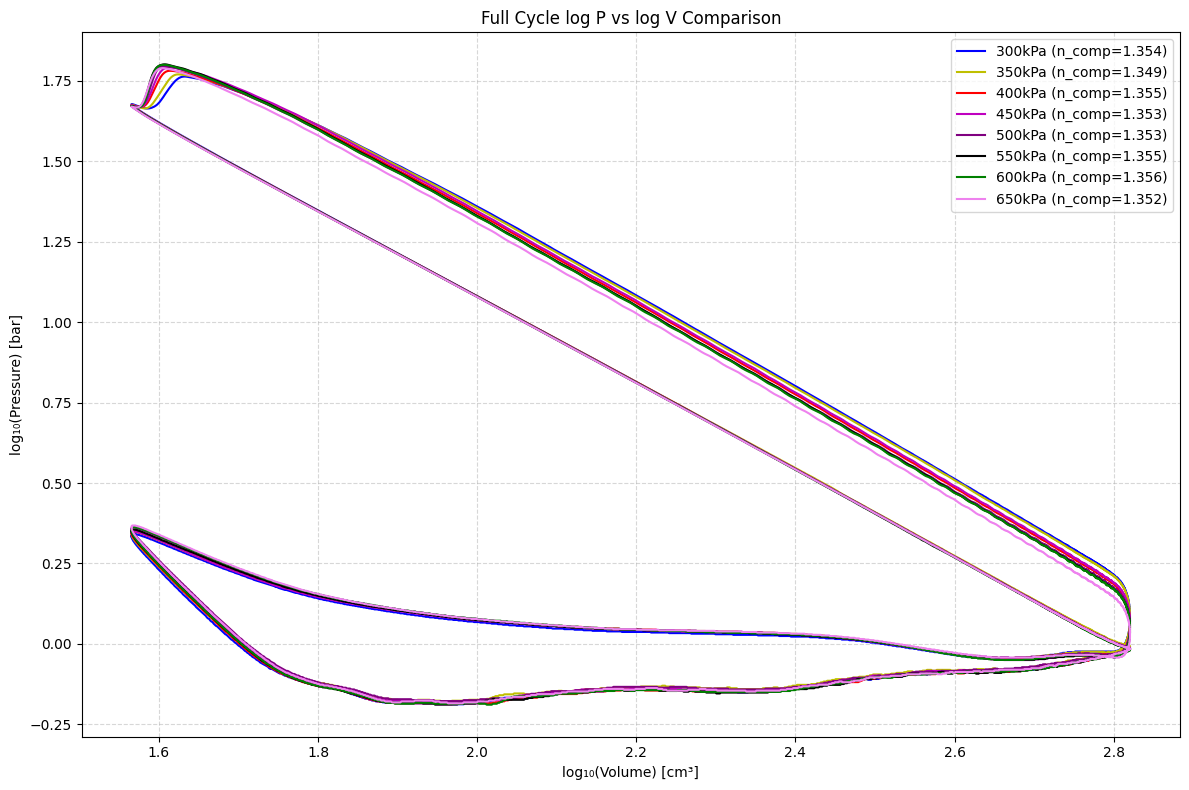

In [24]:
plt.figure(figsize=(12, 8))

for entry in files_to_process:
    try:
        # Load and clean data
        df = pd.read_csv(entry['file'], sep='\t|\r', engine='python',
                         names=['crank_angle', 'pressure_bar'], skiprows=2)
        df = df.apply(pd.to_numeric, errors='coerce').dropna().reset_index(drop=True)

        # Calculate Volume for the full range provided in the file
        df['volume_cm3'] = cylinder_volume(df['crank_angle'])

        # Filter out non-positive values for log calculation
        df = df[(df['pressure_bar'] > 0) & (df['volume_cm3'] > 0)]

        logV_full = np.log10(df['volume_cm3'].values)
        logP_full = np.log10(df['pressure_bar'].values)

        # --- CALCULATION FOR COMPRESSION STROKE (n) ---
        # We isolate the compression part (e.g., -150 to -30 deg) for the slope fit
        comp_mask = (df['crank_angle'] >= -150) & (df['crank_angle'] <= -30)
        logV_comp = np.log10(df.loc[comp_mask, 'volume_cm3'].values)
        logP_comp = np.log10(df.loc[comp_mask, 'pressure_bar'].values)

        if len(logV_comp) > 1:
            slope, intercept = np.polyfit(logV_comp, logP_comp, 1)
            n_comp = -slope
            label_text = f"{entry['label']} (n_comp={n_comp:.3f})"
        else:
            label_text = entry['label']

        # --- PLOT FULL CYCLE ---
        plt.plot(logV_full, logP_full, label=label_text, color=entry['color'], linewidth=1.5)

    except Exception as e:
        print(f"Error processing {entry['file']}: {e}")

# Formatting the Chart
plt.xlabel('log₁₀(Volume) [cm³]')
plt.ylabel('log₁₀(Pressure) [bar]')
plt.title('Full Cycle log P vs log V Comparison')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

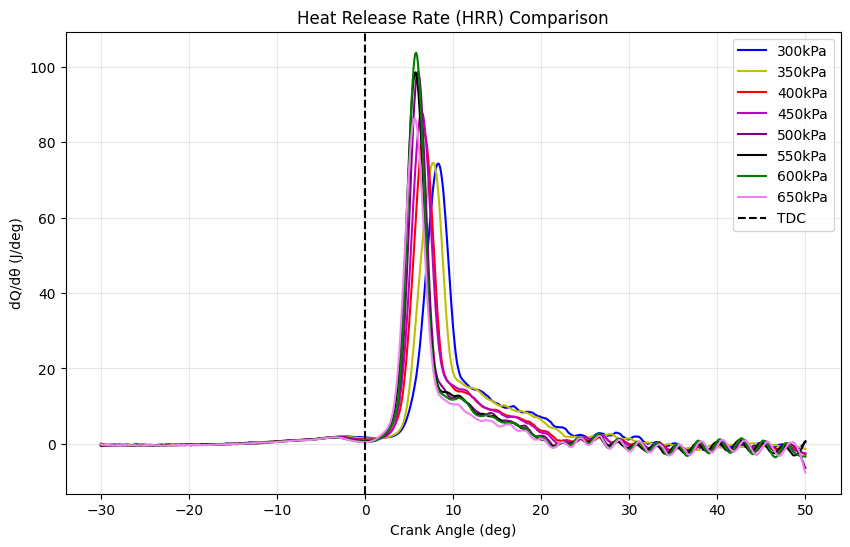

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter # Import savgol_filter

# --- Engine Parameters ---
bore, stroke = 0.093, 0.092
conrod_length = 0.156
rc = 18
gamma = 1.35  # Ratio of specific heats (typical for combustion)
v_swept = np.pi * (bore/2)**2 * stroke
v_c = v_swept / (rc - 1)
piston_area = np.pi * (bore/2)**2

def engine_kinematics(theta_deg):
    theta_rad = np.radians(theta_deg)
    r = stroke / 2
    l = conrod_length
    # Instantaneous Volume
    s = r * (1 - np.cos(theta_rad)) + l - np.sqrt(l**2 - (r * np.sin(theta_rad))**2)
    V = v_c + piston_area * s
    # Volume derivative dV/dtheta (analytical)
    dVdtheta = piston_area * r * np.sin(theta_rad) * (1 + (r * np.cos(theta_rad)) / np.sqrt(l**2 - (r * np.sin(theta_rad))**2))
    return V, dVdtheta

# --- Files to process ---
'''files_to_process = [
    {'file': 'Injection_Timing_24bTDC.txt', 'label': '24° bTDC', 'color': 'b'},
    {'file': 'Injection_Timing_22bTDC.txt', 'label': '22° bTDC', 'color': 'r'},
    {'file': 'Injection_Timing_20bTDC.txt', 'label': '20° bTDC', 'color': 'g'},
    {'file': 'Injection_Timing_18bTDC.txt', 'label': '18° bTDC', 'color': 'y'},
    {'file': 'Injection_Timing_16bTDC.txt', 'label': '16° bTDC', 'color': 'k'},
    {'file': 'Injection_Timing_14bTDC.txt', 'label': '14° bTDC', 'color': 'orange'},
    {'file': 'Injection_Timing_12bTDC.txt', 'label': '12° bTDC', 'color': 'm'},
    {'file': 'Injection_Timing_10bTDC.txt', 'label': '10° bTDC', 'color': 'purple'}
]'''
files = [
    {'file': 'Injection_Pressure_300kPa.txt', 'label': '300kPa', 'color': 'b'},
    {'file': 'Injection_Pressure_350kPa.txt', 'label': '350kPa', 'color': 'y'},
    {'file': 'Injection_Pressure_400kPa.txt', 'label': '400kPa', 'color': 'r'},
    {'file': 'Injection_Pressure_450kPa.txt', 'label': '450kPa', 'color': 'm'},
    {'file': 'Injection_Pressure_500kPa.txt', 'label': '500kPa', 'color': 'purple'},
    {'file': 'Injection_Pressure_550kPa.txt', 'label': '550kPa', 'color': 'k'},
    {'file': 'Injection_Pressure_600kPa.txt', 'label': '600kPa', 'color': 'g'},
    {'file': 'Injection_Pressure_650kPa.txt', 'label': '650kPa', 'color': 'violet'},
]

plt.figure(figsize=(10, 6))

for entry in files:
    try:
        # Use robust separator and convert to numeric, drop NaNs
        df = pd.read_csv(entry['file'], sep='\t|\r', engine='python', names=['theta', 'P_bar'], skiprows=2)
        df = df.apply(pd.to_numeric, errors='coerce').dropna().reset_index(drop=True)

        # Ensure unique crank angles and sort them, then filter
        df = df.drop_duplicates(subset=['theta']).sort_values(by='theta').reset_index(drop=True)
        df = df[(df['theta'] >= -30) & (df['theta'] <= 50)]

        # If after filtering there are not enough points for gradient or smoothing, skip or handle appropriately
        if len(df) < 5: # Need enough points for Savitzky-Golay (poly_order=3 requires at least 5 points for window_length > 3)
            print(f"Not enough data points for {entry['file']} after filtering. Skipping.")
            continue

        theta_deg = df['theta'].values
        P_pa = df['P_bar'].values * 1e5

        # Apply Savitzky-Golay filter to pressure data for smoothing
        # Ensure window_length is odd and less than or equal to the number of data points
        window_length = len(P_pa) if len(P_pa) % 2 == 1 else len(P_pa) - 1
        if window_length > 31: # Cap window length for reasonable smoothing
            window_length = 31
        if window_length < 5: # Minimum requirement for poly_order 3 (or adjust poly_order)
            poly_order = max(1, window_length - 2) # ensure poly_order is less than window_length
        else:
            poly_order = 3

        if window_length >= 3: # Savitzky-Golay requires window_length >= poly_order + 2 (for poly_order=3, need 5. If smaller, adjust poly_order)
            P_pa_smoothed = savgol_filter(P_pa, window_length, poly_order)
        else: # Fallback to no smoothing if too few points for Savitzky-Golay
            P_pa_smoothed = P_pa

        # Calculate V and dV/dtheta for all points
        V, dVdtheta = engine_kinematics(theta_deg)

        # Numerical derivative of Smoothed Pressure (dP/dtheta)
        # Pass np.radians(theta_deg) as the spacing parameter for non-uniform spacing
        dP_dtheta = np.gradient(P_pa_smoothed, np.radians(theta_deg))

        # Calculate HRR (Joules per Radian)
        dQ_drad = (gamma/(gamma-1))*P_pa_smoothed*dVdtheta + (1/(gamma-1))*V*dP_dtheta

        # Convert to Joules per Degree
        dQ_ddeg = dQ_drad * (np.pi / 180)

        # Filter out NaN/Inf values from dQ_ddeg before plotting
        valid_indices = np.isfinite(dQ_ddeg)
        plt.plot(theta_deg[valid_indices], dQ_ddeg[valid_indices], label=entry['label'], color=entry['color'])

    except Exception as e: print(f"Error processing {entry['file']}: {e}")

plt.title("Heat Release Rate (HRR) Comparison")
plt.xlabel("Crank Angle (deg)")
plt.ylabel("dQ/dθ (J/deg)")
plt.axvline(0, color='black', linestyle='--', label='TDC')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

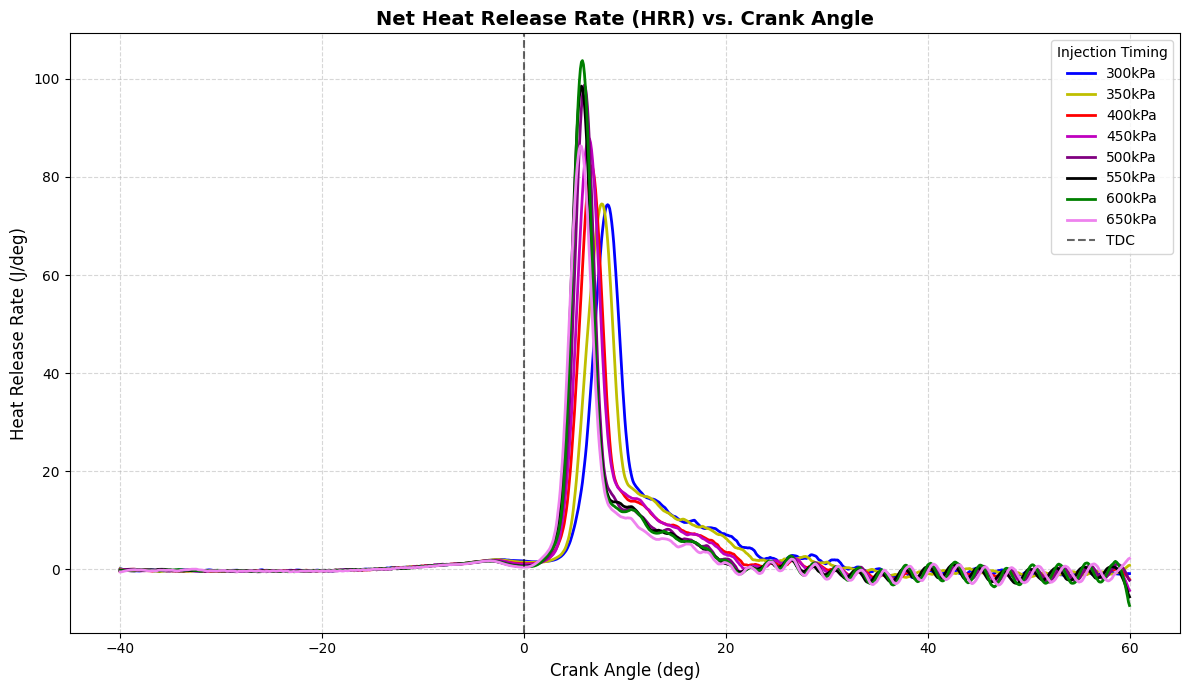

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter # Import savgol_filter

# ===============================================
# 1. ENGINE PARAMETERS (IITKGP Lab Specs) - Using globally defined ones
# ===============================================
# Assuming bore, stroke, conrod_length, rc, clearance_volume, piston_area, gamma are defined globally
# in the first cell, so we don't redefine them here to avoid inconsistencies.
# If these are not globally available, they would need to be passed or redefined.

# Using the engine_kinematics function already defined and refined previously
def engine_kinematics_local(theta_deg):
    """Calculates instantaneous Volume and dV/dtheta using global engine parameters"""
    theta_rad = np.radians(theta_deg)
    r = stroke / 2
    l = conrod_length
    # Instantaneous Volume
    s = r * (1 - np.cos(theta_rad)) + l - np.sqrt(l**2 - (r * np.sin(theta_rad))**2)
    V = clearance_volume + piston_area * s
    # Analytical dV/dtheta
    dVdtheta = piston_area * r * np.sin(theta_rad) * (1 + (r * np.cos(theta_rad)) / np.sqrt(l**2 - (r * np.sin(theta_rad))**2))
    return V, dVdtheta

# ===============================================
# 2. FILE SELECTION & LABELS - Using the full list with colors
# ===============================================
# Re-using 'files_to_process' which contains all files and their colors from cell i0nIb3p532P9
# Ensure this list is defined in an earlier cell or redefine it here if needed
# Assuming files_to_process is already defined as:
files_to_plot = [
    {'file': 'Injection_Pressure_300kPa.txt', 'label': '300kPa', 'color': 'b'},
    {'file': 'Injection_Pressure_350kPa.txt', 'label': '350kPa', 'color': 'y'},
    {'file': 'Injection_Pressure_400kPa.txt', 'label': '400kPa', 'color': 'r'},
    {'file': 'Injection_Pressure_450kPa.txt', 'label': '450kPa', 'color': 'm'},
    {'file': 'Injection_Pressure_500kPa.txt', 'label': '500kPa', 'color': 'purple'},
    {'file': 'Injection_Pressure_550kPa.txt', 'label': '550kPa', 'color': 'k'},
    {'file': 'Injection_Pressure_600kPa.txt', 'label': '600kPa', 'color': 'g'},
    {'file': 'Injection_Pressure_650kPa.txt', 'label': '650kPa', 'color': 'violet'},
]

# ===============================================
# 3. PROCESSING AND PLOTTING
# ===============================================
plt.figure(figsize=(12, 7))

for entry in files_to_plot:
    try:
        # Load and clean data (robust parsing and filtering)
        df = pd.read_csv(entry['file'], sep='\t|\r', engine='python',
                         names=['ca', 'p_bar'], skiprows=2)
        df = df.apply(pd.to_numeric, errors='coerce').dropna().reset_index(drop=True)

        # Ensure unique crank angles and sort them, then filter
        df = df.drop_duplicates(subset=['ca']).sort_values(by='ca').reset_index(drop=True)
        # Focus on the combustion window (-40 to +60 degrees)
        df = df[(df['ca'] >= -40) & (df['ca'] <= 60)]

        # Check for sufficient data points for smoothing
        if len(df) < 5:
            print(f"Not enough data points for {entry['file']} after filtering. Skipping.")
            continue

        ca = df['ca'].values
        P_pa = df['p_bar'].values * 1e5  # Convert bar to Pascals

        # Apply Savitzky-Golay filter to pressure data for smoothing
        window_length = len(P_pa) if len(P_pa) % 2 == 1 else len(P_pa) - 1
        if window_length > 31: window_length = 31
        if window_length < 5: poly_order = max(1, window_length - 2)
        else: poly_order = 3

        if window_length >= 3:
            P_pa_smoothed = savgol_filter(P_pa, window_length, poly_order)
        else:
            P_pa_smoothed = P_pa

        # Calculate kinematics for this CA array
        V, dVdtheta = engine_kinematics_local(ca)

        # Numerical derivative of Smoothed Pressure (Pa/rad)
        # Pass np.radians(ca) as the spacing parameter for non-uniform spacing
        dPdtheta = np.gradient(P_pa_smoothed, np.radians(ca))

        # Net HRR Formula (J/rad)
        dQ_drad = (gamma/(gamma-1))*P_pa_smoothed*dVdtheta + (1/(gamma-1))*V*dPdtheta

        # Convert to J/deg for plotting
        dQ_ddeg = dQ_drad * (np.pi / 180)

        # Filter out NaN/Inf values from dQ_ddeg before plotting
        valid_indices = np.isfinite(dQ_ddeg)
        plt.plot(ca[valid_indices], dQ_ddeg[valid_indices], label=entry['label'], color=entry['color'], linewidth=2)

    except Exception as e:
        print(f"Could not process {entry['file']}: {e}")

# ===============================================
# 4. CHART FORMATTING
# ===============================================
plt.title('Net Heat Release Rate (HRR) vs. Crank Angle', fontsize=14, fontweight='bold')
plt.xlabel('Crank Angle (deg)', fontsize=12)
plt.ylabel('Heat Release Rate (J/deg)', fontsize=12)
plt.axvline(0, color='black', linestyle='--', alpha=0.6, label='TDC')

# Add grid and legend with different bTDC values
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(title="Injection Timing", loc='upper right')

plt.tight_layout()
plt.show()